In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split, KFold

In [4]:
np.random.seed(0)

In [5]:
dogs_whisker_length = np.random.normal(loc=5,scale=1,size=10)
dogs_ear_flappiness_index = np.random.normal(loc=8,scale=1,size=10)

In [15]:
cats_whisker_length = np.random.normal(loc=8,scale=1,size=10)
cats_ear_flappiness_index = np.random.normal(loc=5,scale=1,size=10)

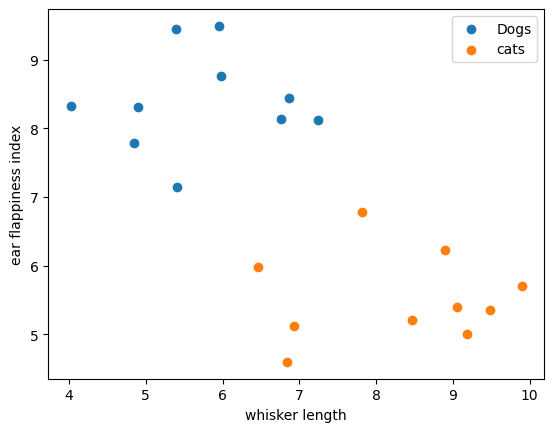

In [19]:
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index,label ='Dogs')
plt.scatter(cats_whisker_length,cats_ear_flappiness_index,label = 'cats')
plt.xlabel('whisker length')
plt.ylabel('ear flappiness index')
plt.legend()

In [22]:
dogs_data = np.vstack((dogs_whisker_length,dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length,cats_ear_flappiness_index)).T

In [30]:
data = np.vstack((dogs_data,cats_data))
labels = np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))

In [32]:
x_train,x_test,y_train,y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

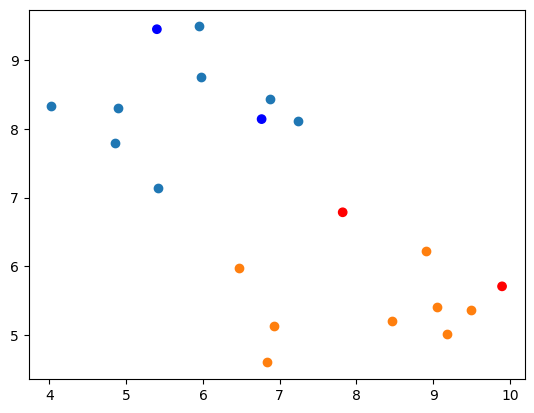

In [33]:
plt.scatter(x_train[y_train ==0][:,0],x_train[y_train==0][:,1],label='Training dogs')
plt.scatter(x_train[y_train ==1][:,0],x_train[y_train==1][:,1],label='Training cats')
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='bwr',label='Testing_data')

In [69]:
def random_linear_classifier(data_dogs,data_cats,k,d):
    best_error = float('inf')
    best_theta =None
    best_theta0 = None

    for i in range(k):
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs,data_cats,theta,theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta0,best_theta,best_error

In [70]:
def compute_error(data_dogs,data_cats,theta,theta0):
    error =0 
    for x_dog in data_dogs:
        if np.dot(theta,x_dog) +theta0 <=0:
            error +=1
    for x_cat in data_cats:

        if np.dot(theta,x_cat) +theta0 >0:
            error +=1
    return error

In [71]:
k=100
d=2
best_theata0,best_theta,train_error = random_linear_classifier(x_train[y_train==0],x_train[y_train==1],k,d)

In [72]:
# plot the dession boundry
x_vals = np.linspace(2,10,100)
y_vals = (-best_theta[0] / best_theta[1]) * x_vals - (best_theata0 / best_theta[1])

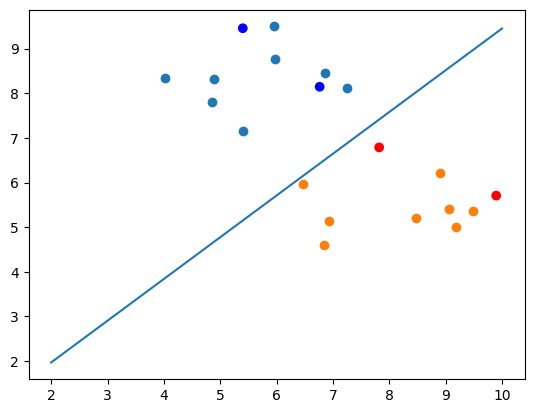

In [73]:
plt.scatter(x_train[y_train ==0][:,0],x_train[y_train==0][:,1],label='Training dogs')
plt.scatter(x_train[y_train ==1][:,0],x_train[y_train==1][:,1],label='Training cats')
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='bwr',label='Testing_data')
plt.plot(x_vals,y_vals)
# plt.xlim([3.5,11])
# plt.ylim([2,10])

In [75]:
print(train_error)

0


In [77]:
test_error = compute_error(x_test[y_test==0],x_test[y_test==1],best_theta,best_theata0)

In [78]:
test_error

0